# 2. Does the quoted cluster rule explain the regional customer list?

> “only clustered HS (more than 1 within 1 km radius area) & each sequencelly within 30 minute window can produce alert & prioritize to be monitor.”

**Scope:** the observed Jambi / South Sumatra customer region, 2019 and 2023. No national extrapolation. **Question:** whether this rule could reproduce selection into the supplied list. This is different from predicting actual fire: `Status` is not used in predictions, matching, or model fitting.

**Finding preview:** the literal point-centered rule does not reproduce the supplied list. It misses many matched customer observations and selects many regional observations not listed. Geography is a stronger explanatory signal, especially in 2023; original provider/product differences affect 2019. No tested feature set proves their original algorithm.

Both notebooks run independently. Run all cells from the top. This notebook rebuilds matching and spatial features when needed; cached results are validated against input and helper-code fingerprints. The spatial algorithms and synthetic tests are readable in `hotspot_filter_analysis/analysis.py`.


## Findings for the supplied files — 11 September 2026

The literal rule does **not** reproduce this regional list. Main analysis: original satellite labels, 500 m matching, each matched archive detection counted once.

| Regional result | 2019 | 2023 |
|---|---:|---:|
| Matched unique archive detections | 7,314 | 15,947 |
| Retained by 1 km / 30 minute rule | 5,433 (74.3%) | 12,436 (78.0%) |
| Matched detections failing the rule | 1,881 | 3,511 |
| Regional archive detections selected by the rule | 157,498 | 54,377 |
| Selected archive detections not matched to the list | 152,065 | 41,941 |

The last row is **not a count of false fire alarms**: the rectangular study region includes places outside the true monitoring boundary, and unlisted detections have unknown alert status.

**Most supported additional factor: monitored geography.** On held-out 2023 dates, a coordinates-only tree reaches list-membership F1 of 0.753, versus 0.358 for satellite/thermal/cluster features. Likely satellite-label corrections leave this result intact (0.765 versus 0.389). Simple confidence/FRP and clustering variants do not identify a stable original rule.

**Interpretation:** a geographic and provider/product selection stage is more plausible than clustering alone. The quote may describe alert prioritization within a broader monitored hotspot list. Without true monitoring boundaries and per-row alert decisions, the original extraction algorithm cannot be uniquely identified.

Narrative findings describe this input snapshot. If you replace inputs, the code rebuilds calculations, but review these written interpretations against the new results.


In [1]:
from pathlib import Path
import sys, json, hashlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / 'data/customer/hotspot_master_2019_2023_2025_2026.xlsx').exists()), None)
if ROOT is None:
    raise FileNotFoundError('Open this notebook from the repository or one of its subdirectories.')
HELPERS = ROOT / 'notebooks/hotspot_filter_analysis'
sys.path.insert(0, str(HELPERS))
import importlib, analysis
importlib.reload(analysis)
from analysis import *
OUT = ROOT / 'notebooks/outputs/hotspot_filter_analysis'
OUT.mkdir(parents=True, exist_ok=True)
RECOMPUTE = False  # True forces reconstruction of intermediate calculations.
customer, satellite, inventory = load_inputs(ROOT)
input_fingerprint = hashlib.sha256((
    inventory[['file','sha256']].to_json() +
    hashlib.sha256((ROOT / 'data/customer/hotspot_master_2019_2023_2025_2026.xlsx').read_bytes()).hexdigest() +
    hashlib.sha256((HELPERS / 'analysis.py').read_bytes()).hexdigest()
).encode()).hexdigest()
print(f'Loaded {len(customer):,} customer records and {len(satellite):,} archive detections.')
print('Run cells from top to bottom: Kernel > Restart Kernel and Run All Cells.')


Loaded 41,455 customer records and 1,521,257 archive detections.
Run cells from top to bottom: Kernel > Restart Kernel and Run All Cells.


In [2]:
candidate_path = OUT / 'matching_candidates.pkl'
match_manifest = OUT / 'matching_cache.json'
cache_ok = (candidate_path.exists() and match_manifest.exists()
            and json.loads(match_manifest.read_text()).get('fingerprint') == input_fingerprint)
if RECOMPUTE or not cache_ok:
    pairs = match_candidates(customer, satellite, radius_km=2)
    pairs.to_pickle(candidate_path)
    match_manifest.write_text(json.dumps({'fingerprint':input_fingerprint, 'radius_km':2}, indent=2))
else:
    pairs = pd.read_pickle(candidate_path)  # Only this locally generated, fingerprinted cache.
matches = select_matches(pairs, radius_km=0.5, offset=7, mode='floor')
strict_matches = select_matches(pairs, radius_km=0.1, offset=7, mode='floor')
print(f'{len(pairs):,} spatial candidates; {len(matches):,} customer rows matched within 500 m.')


1,887,420 spatial candidates; 34,715 customer rows matched within 500 m.


## Operationalize the quote before testing it

1. **Primary, retrospective membership:** a detection has at least one **other** detection with center distance ≤1 km and acquisition-time difference ≤30 minutes. Simultaneous detections count; all supplied satellites may contribute. Every member of a qualifying pair is selected.
2. **Same-satellite / cross-satellite:** restrict qualifying neighbors by satellite identity.
3. **Different acquisition minute:** require a positive time gap. **Strictly prior:** select only a detection that has an earlier neighbor; the first detection in a sequence is not retroactively alerted. Simultaneous pixels are not sequential visits in these variants.
4. **Alternative radius interpretation:** for two points, fitting both inside some 1 km-radius disk permits up to 2 km between centers. The 2 km sensitivity tests this looser interpretation for a two-point cluster. For ≥3 points, counting neighbors within 2 km does not guarantee a common 1 km disk.
5. **Sensitivity grid:** radii 0.5 / 1 / 2 km; windows 0 / 10 / 30 / 60 / 1,440 minutes; total local counts ≥2 / ≥3 / ≥5. Counts are local neighborhoods, not transitive component sizes. With ≥2, membership of a chained connected component is equivalent to having at least one pairwise neighbor; the entire chain need not fit in one 30-minute interval.

The CSV acquisition times supply minutes, so the test does not invent minutes for the hour-only workbook timestamps. It tests acquisition time, not ingestion or alert delivery time, which are unavailable.

**Edge handling:** compute on a rectangle buffered by 0.05 degrees (>5 km here), then score only the unbuffered rectangle. Largest tested radius is 2 km. Adjacent UTC days are processed together, so a pair crossing midnight is retained. No self-counting or duplicate archive rows. Detections at the beginning/end of a supplied year have no neighbors from the missing adjacent year; interpret boundary-day long-window sensitivities accordingly.


In [3]:
print(synthetic_tests())
feature_path=OUT/'regional_features.pkl'
feature_manifest=OUT/'features_cache.json'
cache_ok=(feature_path.exists() and feature_manifest.exists() and
          json.loads(feature_manifest.read_text()).get('fingerprint')==input_fingerprint)
if RECOMPUTE or not cache_ok:
    buffered=regional_features(customer,satellite,progress=True)
    buffered.to_pickle(feature_path)
    feature_manifest.write_text(json.dumps({'fingerprint':input_fingerprint},indent=2))
else:
    buffered=pd.read_pickle(feature_path)
buffered['listed']=buffered.sid.isin(matches.sid)
region=buffered.loc[buffered.inside_region_bbox].copy().reset_index(drop=True)
rules=candidate_rules(region)
QUOTED='r=1km;t=30min;n>=2'
print('Study rectangle:',customer_bbox(customer))
print(f'{len(region):,} regional detections; {len(buffered)-len(region):,} halo detections used only as neighbors.')
assert matches.sid.isin(buffered.sid).all()
assert (buffered['n_1km_30min'] >= buffered['n_0.5km_30min']).all()
assert (buffered['n_1km_60min'] >= buffered['n_1km_30min']).all()


Passed: midnight, chains, self-exclusion, spatial/time boundaries, simultaneous/prior/cross-satellite, matching hour bins, and brute-force neighbor comparisons.
Study rectangle: (np.float64(101.82584), np.float64(-4.0146), np.float64(106.03881836), np.float64(-0.73477989))
267,531 regional detections; 2,697 halo detections used only as neighbors.


## Comparison denominators and uncertainty

**Customer-row recovery** asks how many matched spreadsheet rows pass a rule, including multiple providers. **Unique-detection recovery** counts each matched archive `sid` once. The latter is used to compare candidate sets; neither counts distinct fire events.

An archive detection absent from this list is **unlabeled for alert status**, not an established no-alert or no-fire. Therefore `unlisted_selected` means extra selections relative to this spreadsheet, not confirmed false alarms. `listed_precision_proxy` and `listed_f1_proxy` describe reconstruction of observed list membership only. Missing provider products and unknown concession boundaries can depress these scores.

The bounding rectangle contains land outside the true monitoring footprint. We also show 1 km and 5 km neighborhoods of all customer locations (across both years) as optimistic footprint sensitivities. Those masks use the observed list, are not independent validation areas, and must not be interpreted as recovered concession boundaries.


In [4]:
key_rules=[QUOTED,'r=2km;t=30min;n>=2','r=1km;t=0min;n>=2','quoted_same_satellite',
           'quoted_other_satellite','quoted_different_time','quoted_prior_strict','all_hotspots']
rows=[]
scopes={'regional_bbox':np.ones(len(region),bool),
        'within_5km_observed_footprint':region.nearest_customer_location_km.le(5).to_numpy(),
        'within_1km_observed_footprint':region.nearest_customer_location_km.le(1).to_numpy()}
for scope,scope_mask in scopes.items():
    for year in YEARS:
        mask=scope_mask&region.year.eq(year).to_numpy()
        for name in key_rules:
            rows.append(dict(scope=scope,year=year,rule=name,archive_rows=int(mask.sum()),
                             **selection_metrics(region.loc[mask,'listed'],rules[name][mask])))
rule_summary=pd.DataFrame(rows)
display(rule_summary.loc[rule_summary.scope.eq('regional_bbox')].round(4))
rule_summary.to_csv(OUT/'quoted_rule_comparison.csv',index=False)

customer_scored=customer.merge(matches,left_index=True,right_on='customer_index').merge(
    buffered[['sid','satellite_name','utc','n_1km_30min','n_2km_30min']],on='sid',validate='many_to_one')
customer_scored['passes_quoted']=customer_scored.n_1km_30min.ge(1)
customer_scored['passes_2km']=customer_scored.n_2km_30min.ge(1)
recovery=customer_scored.groupby(['year','Region','Sumber','Satellite']).agg(
    matched_rows=('customer_id','size'),passes=('passes_quoted','sum'),recovery=('passes_quoted','mean'),
    recovery_2km=('passes_2km','mean'))
display(customer_scored.groupby('year').agg(matched_rows=('customer_id','size'),passes=('passes_quoted','sum'),
    recovery=('passes_quoted','mean'),recovery_2km=('passes_2km','mean')).round(4))
recovery.to_csv(OUT/'customer_rule_recovery_by_region_source.csv')
customer_scored.to_csv(OUT/'customer_rule_audit.csv',index=False)


,scope,year,rule,archive_rows,listed_and_selected,unlisted_selected,listed_missed,unlisted_not_selected,selected,listed,listed_recall,listed_precision_proxy,listed_f1_proxy
0,regional_bbox,2019,r=1km;t=30min;n>=2,192749,5433,152065,1881,33370,157498,7314,0.7428,0.0345,0.0659
1,regional_bbox,2019,r=2km;t=30min;n>=2,192749,6523,161325,791,24110,167848,7314,0.8919,0.0389,0.0745
2,regional_bbox,2019,r=1km;t=0min;n>=2,192749,4024,145594,3290,39841,149618,7314,0.5502,0.0269,0.0513
3,regional_bbox,2019,quoted_same_satellite,192749,3852,145577,3462,39858,149429,7314,0.5267,0.0258,0.0492
4,regional_bbox,2019,quoted_other_satellite,192749,2800,38646,4514,146789,41446,7314,0.3828,0.0676,0.1148
5,regional_bbox,2019,quoted_different_time,192749,2544,38678,4770,146757,41222,7314,0.3478,0.0617,0.1048
6,regional_bbox,2019,quoted_prior_strict,192749,1175,19216,6139,166219,20391,7314,0.1607,0.0576,0.0848
7,regional_bbox,2019,all_hotspots,192749,7314,185435,0,0,192749,7314,1.0000,0.0379,0.0731
8,regional_bbox,2023,r=1km;t=30min;n>=2,74782,12436,41941,3511,16894,54377,15947,0.7798,0.2287,0.3537
9,regional_bbox,2023,r=2km;t=30min;n>=2,74782,13427,45254,2520,13581,58681,15947,0.8420,0.2288,0.3598


,matched_rows,passes,recovery,recovery_2km
year,,,,
2019,7465,5571,0.7463,0.8932
2023,27250,21659,0.7948,0.8541


**Finding — many listed detections are not clustered under the quote.** The unique-detection recovery is 74.3% in 2019 and 78.0% in 2023. Counting spreadsheet rows instead gives 74.6% and 79.5%; repeated providers explain the difference in denominator. A strictly prior, different-minute neighbor retains only 16.1% and 6.6% of matched unique detections. Therefore the literal interpretation “a later observation within 30 minutes” is particularly incompatible with the list. Many qualifying clusters consist of simultaneous pixels rather than repeated observations over time.


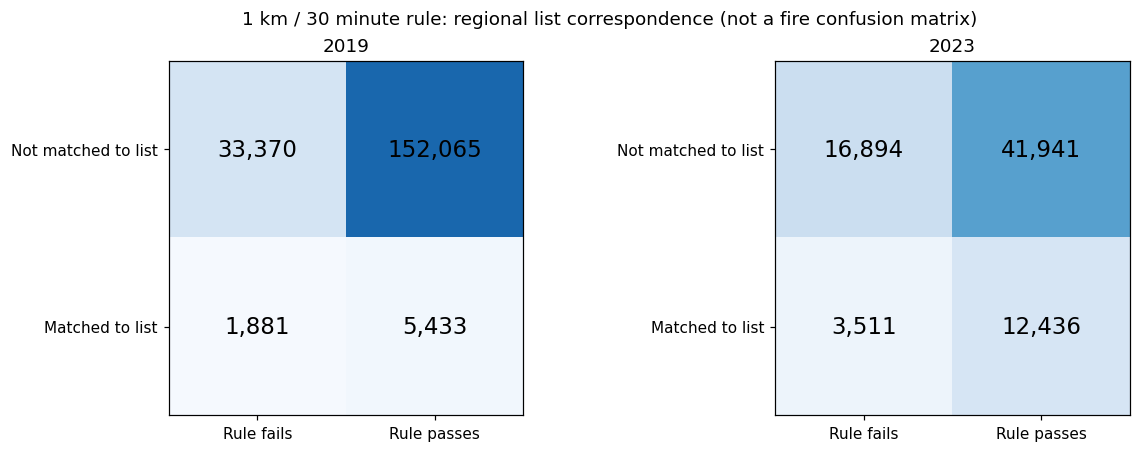

Footprint sensitivity for the quoted rule:


,scope,year,archive_rows,selected,listed,listed_recall,listed_precision_proxy
0,regional_bbox,2019,192749,157498,7314,0.7428,0.0345
8,regional_bbox,2023,74782,54377,15947,0.7798,0.2287
16,within_5km_observed_footprint,2019,72382,61757,7314,0.7428,0.0880
24,within_5km_observed_footprint,2023,21873,16484,15947,0.7798,0.7544
32,within_1km_observed_footprint,2019,50707,43069,7314,0.7428,0.1261
40,within_1km_observed_footprint,2023,17750,13438,15947,0.7798,0.9254


In [5]:
# Visualize unique-detection list membership, not fire verification.
fig,axes=plt.subplots(1,2,figsize=(11,4),constrained_layout=True)
for ax,year in zip(axes,YEARS):
    row=rule_summary.loc[rule_summary.scope.eq('regional_bbox')&rule_summary.year.eq(year)&rule_summary.rule.eq(QUOTED)].iloc[0]
    matrix=np.array([[row.unlisted_not_selected,row.unlisted_selected],[row.listed_missed,row.listed_and_selected]],dtype=int)
    ax.imshow(matrix/matrix.sum(),cmap='Blues',vmin=0,vmax=1)
    for i in range(2):
        for j in range(2): ax.text(j,i,f'{matrix[i,j]:,}',ha='center',va='center',fontsize=15)
    ax.set(title=str(year),xticks=[0,1],yticks=[0,1],xticklabels=['Rule fails','Rule passes'],
           yticklabels=['Not matched to list','Matched to list'])
fig.suptitle('1 km / 30 minute rule: regional list correspondence (not a fire confusion matrix)')
fig.savefig(OUT/'quoted_rule_list_matrices.png',dpi=170);plt.show()
print('Footprint sensitivity for the quoted rule:')
display(rule_summary.loc[rule_summary.rule.eq(QUOTED),['scope','year','archive_rows','selected','listed','listed_recall','listed_precision_proxy']].round(4))


**Finding — the geographic denominator strongly changes apparent agreement.** In 2023, the fraction of rule selections matched to the list rises from 22.9% in the broad regional rectangle to 75.4% within 5 km of observed customer locations, and 92.5% within 1 km. Yet recovery remains 78.0%: geographic trimming removes extra selections but does not make the isolated listed hotspots clustered. These proximity masks were derived from the list itself, so their high agreement is an optimistic sensitivity, not proof of the customer's boundary or an independently validated extraction rule.


## Does positional ambiguity change the conclusion?

Repeat recovery at 100 m and 500 m. For each customer row, evaluate **all** qualifying same-satellite, same-local-hour candidates rather than just the nearest. `all_candidates_pass` is the pessimistic bound and `any_candidate_passes` is the optimistic bound within that tolerance; neither covers the uncertainty of records with no match. The nearest-choice rate lies between them. The 100 m subset has a different source/satellite composition and is not an unbiased sample of all customer rows.


In [6]:
ambiguity=[]
for radius in [.1,.5]:
    allowed=pairs.loc[pairs.same_satellite & time_mask(pairs,7,'floor') & pairs.distance_km.le(radius)].merge(
        buffered[['sid','n_1km_30min']],on='sid',validate='many_to_one')
    allowed['passes']=allowed.n_1km_30min.ge(1)
    bounds_per_row=allowed.groupby('customer_index').passes.agg(['min','max','size'])
    chosen=select_matches(pairs,radius).merge(buffered[['sid','n_1km_30min']],on='sid')
    for year in YEARS:
        b=bounds_per_row.loc[customer.loc[bounds_per_row.index,'year'].eq(year).to_numpy()]
        ch=chosen.loc[customer.loc[chosen.customer_index,'year'].eq(year).to_numpy()]
        ambiguity.append(dict(year=year,match_radius_m=radius*1000,matched_rows=len(b),
            all_candidates_pass=b['min'].mean(),nearest_candidate_pass=ch.n_1km_30min.ge(1).mean(),
            any_candidate_passes=b['max'].mean(),ambiguous_rows=int(b['size'].gt(1).sum())))
ambiguity=pd.DataFrame(ambiguity)
display(ambiguity.round(4));ambiguity.to_csv(OUT/'matching_ambiguity_rule_bounds.csv',index=False)

# High-confidence counterexamples: <=100 m, exactly one candidate, no peer even under 2 km.
counterexamples=customer.merge(strict_matches.loc[strict_matches.candidate_count.eq(1)],left_index=True,right_on='customer_index').merge(
    buffered[['sid','utc','latitude','longitude','n_1km_30min','n_2km_30min','n_1km_60min','n_1km_1440min']],on='sid')
counterexamples=counterexamples.loc[counterexamples.n_2km_30min.eq(0)]
display(counterexamples.groupby(['year','Sumber','Satellite']).size().rename('isolated_even_at_2km'))
display(counterexamples[['customer_id','year','Satellite','Sumber','Tgl_Hotspot','utc','distance_km','n_1km_30min','n_2km_30min']].head(12))
counterexamples.to_csv(OUT/'high_confidence_rule_counterexamples.csv',index=False)


,year,match_radius_m,matched_rows,all_candidates_pass,nearest_candidate_pass,any_candidate_passes,ambiguous_rows
0,2019,100.0,3631,0.5728,0.5728,0.5728,0
1,2023,100.0,22817,0.7913,0.7913,0.7913,438
2,2019,500.0,7465,0.7463,0.7463,0.7463,2473
3,2023,500.0,27250,0.7948,0.7948,0.7948,16903


year  Sumber  Satellite
2019  LAPAN   Aqua          138
              Terra         430
2023  LAPAN   Aqua            5
              NOAA20        523
              SNPP          455
      NASA    Aqua           81
              NOAA20       1217
              SNPP         1129
Name: isolated_even_at_2km, dtype: int64

,customer_id,year,Satellite,Sumber,Tgl_Hotspot,utc,distance_km,n_1km_30min,n_2km_30min
1,2019:3,2019,Terra,LAPAN,2019-01-04 10:00:00,2019-01-04 03:29:00,0.038728,0,0
2,2019:4,2019,Terra,LAPAN,2019-01-04 10:00:00,2019-01-04 03:29:00,0.036340,0,0
4,2019:6,2019,Terra,LAPAN,2019-01-04 10:00:00,2019-01-04 03:29:00,0.035680,0,0
6,2019:8,2019,Aqua,LAPAN,2019-02-03 13:00:00,2019-02-03 06:36:00,0.027619,0,0
7,2019:9,2019,Terra,LAPAN,2019-02-05 10:00:00,2019-02-05 03:28:00,0.046260,0,0
8,2019:10,2019,Terra,LAPAN,2019-02-18 22:00:00,2019-02-18 15:18:00,0.019914,0,0
9,2019:13,2019,Aqua,LAPAN,2019-02-21 13:00:00,2019-02-21 06:24:00,0.028818,0,0
10,2019:14,2019,Aqua,LAPAN,2019-02-21 13:00:00,2019-02-21 06:24:00,0.036836,0,0
11,2019:16,2019,Aqua,LAPAN,2019-02-23 13:00:00,2019-02-23 06:11:00,0.071230,0,0
13,2019:19,2019,Terra,LAPAN,2019-03-07 10:00:00,2019-03-07 03:41:00,0.037749,0,0


**Finding — ambiguous nearest-pixel choices do not explain this mismatch.** For the supplied data, all-candidate and any-candidate rule-recovery bounds coincide at each tested tolerance. At 500 m, they are 74.6% in 2019 and 79.5% in 2023 at the customer-row level. Restricting to uniquely matched 100 m correspondences still leaves 568 customer rows in 2019 and 3,410 in 2023 with no neighbor even within the looser 2 km / 30 minute interpretation. These are customer records, not deduplicated event counts. They provide inspectable counterexamples to the assertion that every spreadsheet row had to satisfy the cluster condition, conditional on the supplied archive representing the original detections.


## Test alternative selection features

Sweep neighborhood size/time and point-level confidence, fire radiative power (FRP), daytime, and archive `type`. These are hypotheses, not recovered requirements. Confidence scales differ: MODIS has a numeric score; VIIRS has low/nominal/high categories, mapped to 0/50/100 solely as an ordinal convenience. Thus a threshold of 50 means nominal-or-high VIIRS or MODIS ≥50, not the same probability across instruments. Brightness channels also differ between instruments.

`type` is an archive attribute and may not have been available in the original real-time pipeline. Most quality rules below act **after** clustering. A separate test removes low-confidence detections **before** finding neighbors to expose order-of-operations effects.

Ranking uses observed-list F1 only. The best rule on 2019 is selected without 2023 labels, then evaluated on 2023. A reverse transfer is a separate experiment. Year-specific rankings are descriptive; changing the rule after seeing the other year would invalidate that holdout.


In [7]:
quality_buffer=buffered.loc[buffered.confidence_score.ge(50)].copy()
quality_neighbors=neighbor_features(quality_buffer,radii=(1.0,),windows=(30,))
quality_selected=set(quality_neighbors.loc[quality_neighbors.n_1km_30min.ge(1),'sid'])
rules['quality_first_then_quoted']=region.sid.isin(quality_selected).to_numpy()
sweep_rows=[]
for year in YEARS:
    mask=region.year.eq(year).to_numpy()
    for name,pred in rules.items():
        sweep_rows.append(dict(year=year,rule=name,**selection_metrics(region.loc[mask,'listed'],pred[mask])))
sweep=pd.DataFrame(sweep_rows)
for year in YEARS:
    print(f'{year}: descriptive ranking (membership proxies only)')
    display(sweep.loc[sweep.year.eq(year)].sort_values('listed_f1_proxy',ascending=False).head(8).round(4))
transfer=[]
for train_year,test_year in [(2019,2023),(2023,2019)]:
    best=sweep.loc[sweep.year.eq(train_year)].sort_values(['listed_f1_proxy','rule'],ascending=[False,True]).iloc[0]
    test=sweep.loc[sweep.year.eq(test_year)&sweep.rule.eq(best.rule)].iloc[0]
    transfer.append(dict(train_year=train_year,test_year=test_year,selected_rule=best.rule,
        train_f1_proxy=best.listed_f1_proxy,test_f1_proxy=test.listed_f1_proxy,
        test_list_recall=test.listed_recall,test_precision_proxy=test.listed_precision_proxy))
transfer=pd.DataFrame(transfer);display(transfer.round(4))
sweep.to_csv(OUT/'candidate_rule_sweep.csv',index=False)
transfer.to_csv(OUT/'candidate_rule_year_transfer.csv',index=False)


2019: descriptive ranking (membership proxies only)


,year,rule,listed_and_selected,unlisted_selected,listed_missed,unlisted_not_selected,selected,listed,listed_recall,listed_precision_proxy,listed_f1_proxy
52,2019,confidence>=80_only,1850,13706,5464,171729,15556,7314,0.2529,0.1189,0.1618
58,2019,FRP>=20_only,2604,24168,4710,161267,26772,7314,0.3560,0.0973,0.1528
57,2019,FRP>=10_only,4749,51569,2565,133866,56318,7314,0.6493,0.0843,0.1493
61,2019,quoted + high_confidence_only,1305,11232,6009,174203,12537,7314,0.1784,0.1041,0.1315
68,2019,quoted + FRP>=20,1931,20866,5383,164569,22797,7314,0.2640,0.0847,0.1283
67,2019,quoted + FRP>=10,3474,44724,3840,140711,48198,7314,0.4750,0.0721,0.1252
56,2019,FRP>=5_only,6715,94784,599,90651,101499,7314,0.9181,0.0662,0.1234
46,2019,quoted_other_satellite,2800,38646,4514,146789,41446,7314,0.3828,0.0676,0.1148


2023: descriptive ranking (membership proxies only)


,year,rule,listed_and_selected,unlisted_selected,listed_missed,unlisted_not_selected,selected,listed,listed_recall,listed_precision_proxy,listed_f1_proxy
115,2023,r=2km;t=1440min;n>=5,12964,40317,2983,18518,53281,15947,0.8129,0.2433,0.3745
114,2023,r=2km;t=1440min;n>=3,14327,46517,1620,12318,60844,15947,0.8984,0.2355,0.3731
111,2023,r=2km;t=60min;n>=3,12900,41023,3047,17812,53923,15947,0.8089,0.2392,0.3693
99,2023,r=1km;t=1440min;n>=3,13574,44136,2373,14699,57710,15947,0.8512,0.2352,0.3686
98,2023,r=1km;t=1440min;n>=2,14817,50147,1130,8688,64964,15947,0.9291,0.2281,0.3663
83,2023,r=0.5km;t=1440min;n>=2,14036,46761,1911,12074,60797,15947,0.8802,0.2309,0.3658
113,2023,r=2km;t=1440min;n>=2,15120,51676,827,7159,66796,15947,0.9481,0.2264,0.3655
95,2023,r=1km;t=60min;n>=2,13760,45832,2187,13003,59592,15947,0.8629,0.2309,0.3643


,train_year,test_year,selected_rule,train_f1_proxy,test_f1_proxy,test_list_recall,test_precision_proxy
0,2019,2023,confidence>=80_only,0.1618,0.0767,0.0497,0.1683
1,2023,2019,r=2km;t=1440min;n>=5,0.3745,0.0771,0.8953,0.0403


**Finding — no stable simple threshold emerges.** The highest 2019 list-F1 among the tested candidates is the confidence≥80-only rule, but it recovers only 25.3% of matched listed detections; its list-F1 falls from 0.162 in 2019 to 0.077 in 2023. The best 2023 candidate is the much looser 2 km / 24 hour / ≥5 local-points rule (F1 0.375), only modestly above the quoted rule's 0.354, and it transfers poorly to 2019. These rankings are not evidence that the team used either threshold. They show that replacing the quote with a single tested threshold does not solve the reconstruction problem.


detections  ...  cluster_fraction
year satellite_name listed              ...                  
2019 Aqua           False         8823  ...             0.854
                    True          2143  ...             0.852
     NOAA20         False        85314  ...             0.832
                    True          1633  ...             0.899
     SNPP           False        85058  ...             0.847
                    True          2046  ...             0.927
     Terra          False         6240  ...             0.240
                    True          1492  ...             0.162
2023 Aqua           False         3709  ...             0.705
                    True           979  ...             0.669
     NOAA20         False        25417  ...             0.728
                    True          7633  ...             0.781
     SNPP           False        26998  ...             0.749
                    True          7335  ...             0.793
     Terra          False         2711  ...             0.216

[15 rows x 5 columns]

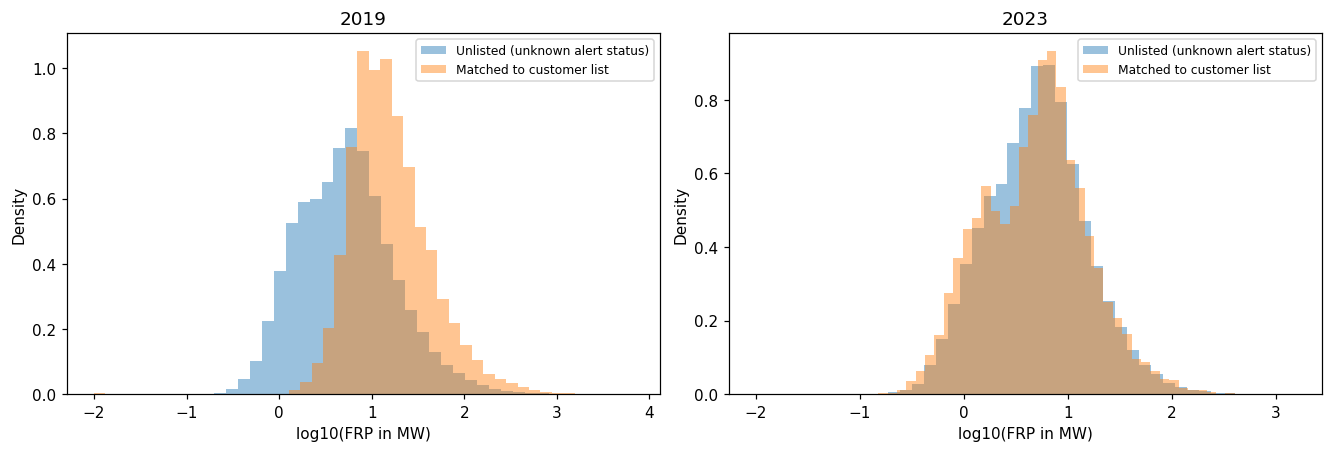

In [8]:
feature_summary=region.groupby(['year','satellite_name','listed']).agg(
    detections=('sid','size'),frp_median=('frp','median'),confidence_median=('confidence_score','median'),
    day_fraction=('daynight',lambda x:x.eq('D').mean()),cluster_fraction=('n_1km_30min',lambda x:x.ge(1).mean()))
display(feature_summary.round(3))
feature_summary.to_csv(OUT/'feature_summary_by_satellite.csv')
fig,axes=plt.subplots(1,2,figsize=(12,4),constrained_layout=True)
for ax,year in zip(axes,YEARS):
    selected=region.loc[region.year.eq(year)&region.listed]
    absent=region.loc[region.year.eq(year)&~region.listed]
    ax.hist(np.log10(absent.frp.clip(lower=.01)),bins=45,density=True,alpha=.45,label='Unlisted (unknown alert status)')
    ax.hist(np.log10(selected.frp.clip(lower=.01)),bins=45,density=True,alpha=.45,label='Matched to customer list')
    ax.set(title=str(year),xlabel='log10(FRP in MW)',ylabel='Density');ax.legend(fontsize=8)
fig.savefig(OUT/'frp_distributions.png',dpi=160);plt.show()


**Finding — source-specific associations are stronger than a universal FRP cutoff.** Matched 2019 NOAA20 and SNPP detections have median FRP of 11.56 and 9.27 MW, versus 4.49 and 4.66 MW among unlisted regional detections. In 2023 the corresponding listed/unlisted medians are much closer (NOAA20 4.83/4.46 MW; SNPP 4.81/4.38 MW). All matched 2019 ASMC/NOAA20 rows are daytime detections. This suggests differing feed/product or monitoring practices across years. It does not distinguish deliberate FRP filtering from differences in original product resolution or detectability.


## Can a small model identify a more plausible selection pattern?

Fit shallow decision trees (depth 4, ≥100 observations per leaf, balanced class weights, fixed seed) to list membership using: (a) satellite/thermal/cluster features; (b) coordinates only; (c) satellite features plus coordinates and local hour. There is **no fire status, provider, customer-region label, or distance to a customer point in the predictors**.

Within each year, hold out every fifth sorted UTC date in full, keeping a satellite acquisition date out of training. This tests reconstruction on different dates in the same region, not generalization to new concessions. Dates are interleaved, so it is not a prospective forecasting test. Separate full-year fits evaluate transfer to the other year. Missing numeric values use training-set medians only. The neighbor features are retrospective; these trees are exploratory, not operational early-warning models.

Unknown monitoring boundaries and unlisted-but-monitored observations remain confounders. Location splits can describe the footprint but cannot establish contractual concession boundaries. Feature importance measures a fitted model's associations, not the team's historical feature choices.


In [9]:
tree_metrics,tree_text,importance=fit_exploratory_trees(region)
display(tree_metrics.round(4))
tree_metrics.to_csv(OUT/'exploratory_tree_metrics.csv',index=False)
importance.to_csv(OUT/'exploratory_tree_importance.csv',index=False)
(OUT/'exploratory_tree_rules.json').write_text(json.dumps(tree_text,indent=2)+'\n')
for year in YEARS:
    key=f'{year}_heldout_dates_satellite_features_plus_location_hour'
    print(f'\n{year}: learned reconstruction tree (not a recovered original rule)\n')
    print(tree_text[key])
# Same-date test baselines make the tree comparisons directly comparable.
heldout_baselines=[]
for year in YEARS:
    yr=region.year.eq(year)
    test_dates=np.sort(region.loc[yr,'utc'].dt.normalize().unique())[::5]
    mask=yr&region.utc.dt.normalize().isin(test_dates)
    for name in [QUOTED,'all_hotspots']:
        heldout_baselines.append(dict(year=year,rule=name,**selection_metrics(region.loc[mask,'listed'],rules[name][mask])))
heldout_baselines=pd.DataFrame(heldout_baselines)
display(heldout_baselines.round(4));heldout_baselines.to_csv(OUT/'heldout_date_baselines.csv',index=False)


,train_year,test_year,experiment,features,train_rows,test_rows,listed_and_selected,unlisted_selected,listed_missed,unlisted_not_selected,selected,listed,listed_recall,listed_precision_proxy,listed_f1_proxy
0,2019,2019,heldout_dates,satellite_features,153824,38925,1102,8518,432,28873,9620,1534,0.7184,0.1146,0.1976
1,2019,2023,other_year,satellite_features,192749,74782,5934,21578,10013,37257,27512,15947,0.3721,0.2157,0.2731
2,2019,2019,heldout_dates,location_only,153824,38925,1334,9453,200,27938,10787,1534,0.8696,0.1237,0.2165
3,2019,2023,other_year,location_only,192749,74782,12753,5699,3194,53136,18452,15947,0.7997,0.6911,0.7415
4,2019,2019,heldout_dates,satellite_features_plus_location_hour,153824,38925,1317,5619,217,31772,6936,1534,0.8585,0.1899,0.3110
5,2019,2023,other_year,satellite_features_plus_location_hour,192749,74782,8743,10726,7204,48109,19469,15947,0.5483,0.4491,0.4937
6,2023,2023,heldout_dates,satellite_features,58213,16569,2149,6128,1583,6709,8277,3732,0.5758,0.2596,0.3579
7,2023,2019,other_year,satellite_features,74782,192749,2301,70339,5013,115096,72640,7314,0.3146,0.0317,0.0576
8,2023,2023,heldout_dates,location_only,58213,16569,3560,2167,172,10670,5727,3732,0.9539,0.6216,0.7527
9,2023,2019,other_year,location_only,74782,192749,6644,90595,670,94840,97239,7314,0.9084,0.0683,0.1271



2019: learned reconstruction tree (not a recovered original rule)

|--- frp <= 5.395
|   |--- frp <= 2.795
|   |   |--- frp <= 1.685
|   |   |   |--- brightness_main <= 321.955
|   |   |   |   |--- class: False
|   |   |   |--- brightness_main >  321.955
|   |   |   |   |--- class: False
|   |   |--- frp >  1.685
|   |   |   |--- satellite_name_NOAA20 <= 0.500
|   |   |   |   |--- class: False
|   |   |   |--- satellite_name_NOAA20 >  0.500
|   |   |   |   |--- class: False
|   |--- frp >  2.795
|   |   |--- longitude <= 105.341
|   |   |   |--- track <= 0.890
|   |   |   |   |--- class: False
|   |   |   |--- track >  0.890
|   |   |   |   |--- class: True
|   |   |--- longitude >  105.341
|   |   |   |--- latitude <= -2.523
|   |   |   |   |--- class: True
|   |   |   |--- latitude >  -2.523
|   |   |   |   |--- class: False
|--- frp >  5.395
|   |--- longitude <= 105.189
|   |   |--- track <= 0.890
|   |   |   |--- latitude <= -2.500
|   |   |   |   |--- class: False
|   |   |   |-

,year,rule,listed_and_selected,unlisted_selected,listed_missed,unlisted_not_selected,selected,listed,listed_recall,listed_precision_proxy,listed_f1_proxy
0,2019,r=1km;t=30min;n>=2,1088,30803,446,6588,31891,1534,0.7093,0.0341,0.0651
1,2019,all_hotspots,1534,37391,0,0,38925,1534,1.0000,0.0394,0.0758
2,2023,r=1km;t=30min;n>=2,3059,9263,673,3574,12322,3732,0.8197,0.2483,0.3811
3,2023,all_hotspots,3732,12837,0,0,16569,3732,1.0000,0.2252,0.3677


**Finding — location explains much of 2023 list membership.** On held-out dates, coordinates alone achieve F1 0.753 and list recovery 95.4%, compared with F1 0.358 for satellite/thermal/cluster features. Adding those features to coordinates gives the same 2023 predictions in this shallow-tree experiment. The learned splits mainly outline the observed spatial footprint. A location-only model trained on 2019 also attains F1 0.742 on 2023, supporting geographic consistency across years. In the reverse direction performance is much weaker, consistent with 2019's poor source matching and different sampling. These are list-reconstruction results in the same broad region, not validated fire-detection scores or recovered concession boundaries.


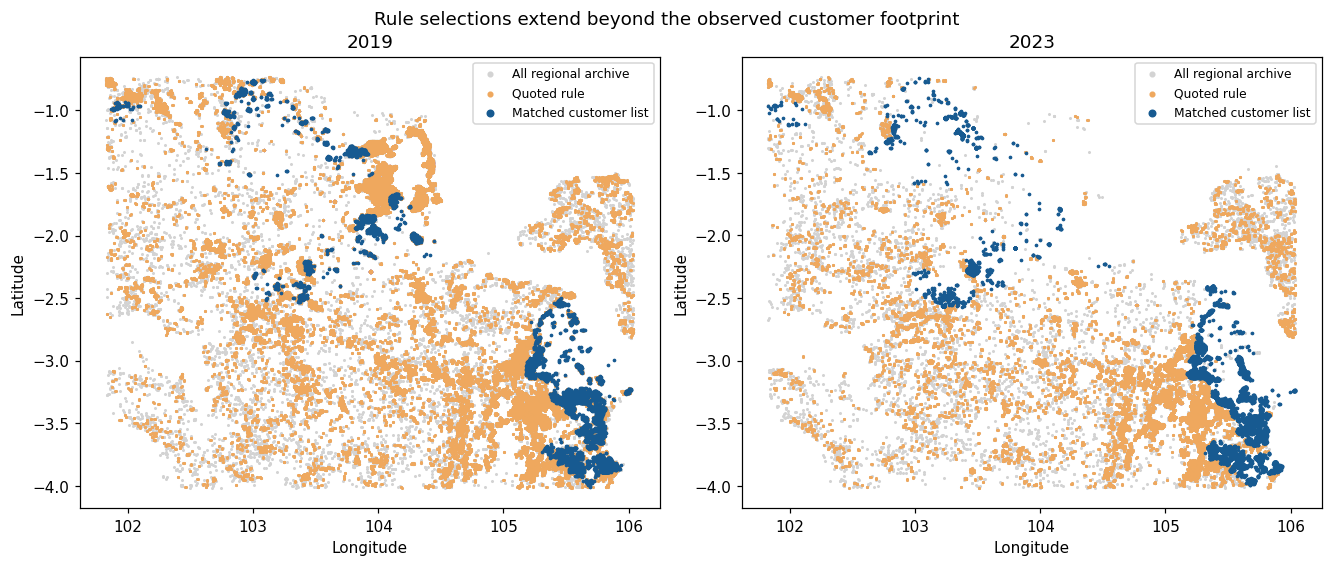

All regional detections, features, list membership, and rule decisions exported for inspection.


In [10]:
fig,axes=plt.subplots(1,2,figsize=(12,5),constrained_layout=True)
for ax,year in zip(axes,YEARS):
    mask=region.year.eq(year)
    s=region.loc[mask]
    ax.scatter(s.longitude,s.latitude,s=1,c='lightgray',rasterized=True,label='All regional archive')
    selected=region.loc[mask & rules[QUOTED]]
    ax.scatter(selected.longitude,selected.latitude,s=1,c='#efa85e',rasterized=True,label='Quoted rule')
    listed=region.loc[mask & region.listed]
    ax.scatter(listed.longitude,listed.latitude,s=2,c='#175a91',rasterized=True,label='Matched customer list')
    ax.set(title=str(year),xlabel='Longitude',ylabel='Latitude',aspect='equal');ax.legend(markerscale=3,fontsize=8)
fig.suptitle('Rule selections extend beyond the observed customer footprint')
fig.savefig(OUT/'regional_rule_map.png',dpi=170);plt.show()
export_columns=['sid','sat_id','year','utc','latitude','longitude','satellite_name','instrument','confidence','confidence_score',
    'frp','daynight','type','listed','nearest_customer_location_km']+[c for c in region if c.startswith('n_')]
export=region[export_columns].copy();export['passes_quoted_rule']=rules[QUOTED]
export.to_csv(OUT/'regional_detection_audit.csv.gz',index=False,compression='gzip')
print('All regional detections, features, list membership, and rule decisions exported for inspection.')


## Satellite-label correction sensitivity

Notebook 1 finds strong evidence that some Aqua labels actually refer to Terra. Preserve the source workbook and the primary named-satellite analysis. In a separate scenario, add an alternative match only when the primary 500 m match is missing, the original satellite is known, and exactly one candidate across all satellites lies within 100 m and the inferred local-hour window. These are likely corrections, not verified provenance.

Repeat the unique-detection rule comparison and the exploratory model tests. This checks whether labeling errors explain the earlier conclusions. Also report how many isolated listed detections have repeated provider reports: counting those reports as separate hotspots could artificially satisfy a two-hotspot rule, but they are not independent detections and cannot be used to infer selection on unseen rows.


In [11]:
rescued=select_matches(pairs,.1,7,'floor',any_satellite=True)
rescued=rescued.loc[~rescued.customer_index.isin(matches.customer_index) &
    ~rescued.same_satellite & ~rescued.unknown_satellite & rescued.candidate_count.eq(1)]
corrected_matches=pd.concat([matches,rescued],ignore_index=True)
assert corrected_matches.customer_index.is_unique
corrected=region.copy();corrected['listed']=corrected.sid.isin(corrected_matches.sid)
correction_rows=[]
for scenario,frame in [('original_labels',region),('likely_label_corrections',corrected)]:
    for year in YEARS:
        g=frame.loc[frame.year.eq(year)]
        correction_rows.append(dict(scenario=scenario,year=year,
            **selection_metrics(g.listed,g.n_1km_30min.ge(1))))
correction_summary=pd.DataFrame(correction_rows)
display(correction_summary.round(4))
correction_summary.to_csv(OUT/'label_correction_rule_sensitivity.csv',index=False)
corrected_matches.to_csv(OUT/'matches_label_correction_sensitivity.csv',index=False)
corrected_tree_metrics,_,_=fit_exploratory_trees(corrected)
display(corrected_tree_metrics.loc[corrected_tree_metrics.experiment.eq('heldout_dates')].round(4))
corrected_tree_metrics.to_csv(OUT/'label_correction_tree_sensitivity.csv',index=False)
provider_counts=customer.merge(matches,left_index=True,right_on='customer_index').groupby('sid').Sumber.nunique()
duplicate_effect=region.loc[region.listed & region.n_1km_30min.eq(0)].copy()
duplicate_effect['multiple_providers']=duplicate_effect.sid.map(provider_counts).gt(1)
display(duplicate_effect.groupby('year').agg(isolated_listed=('sid','size'),
    isolated_with_multiple_provider_reports=('multiple_providers','sum')))


,scenario,year,listed_and_selected,unlisted_selected,listed_missed,unlisted_not_selected,selected,listed,listed_recall,listed_precision_proxy,listed_f1_proxy
0,original_labels,2019,5433,152065,1881,33370,157498,7314,0.7428,0.0345,0.0659
1,original_labels,2023,12436,41941,3511,16894,54377,15947,0.7798,0.2287,0.3537
2,likely_label_corrections,2019,5462,152036,1881,33370,157498,7343,0.7438,0.0347,0.0663
3,likely_label_corrections,2023,12538,41839,3966,16439,54377,16504,0.7597,0.2306,0.3538


,train_year,test_year,experiment,features,train_rows,test_rows,listed_and_selected,unlisted_selected,listed_missed,unlisted_not_selected,selected,listed,listed_recall,listed_precision_proxy,listed_f1_proxy
0,2019,2019,heldout_dates,satellite_features,153824,38925,1102,8518,435,28870,9620,1537,0.7170,0.1146,0.1975
2,2019,2019,heldout_dates,location_only,153824,38925,1336,9452,201,27936,10788,1537,0.8692,0.1238,0.2168
4,2019,2019,heldout_dates,satellite_features_plus_location_hour,153824,38925,1318,5618,219,31770,6936,1537,0.8575,0.1900,0.3111
6,2023,2023,heldout_dates,satellite_features,58213,16569,2822,7842,1043,4862,10664,3865,0.7301,0.2646,0.3885
8,2023,2023,heldout_dates,location_only,58213,16569,3650,2033,215,10671,5683,3865,0.9444,0.6423,0.7646
10,2023,2023,heldout_dates,satellite_features_plus_location_hour,58213,16569,3650,2033,215,10671,5683,3865,0.9444,0.6423,0.7646


,isolated_listed,isolated_with_multiple_provider_reports
year,,
2019,1881,0
2023,3511,2074


**Finding — likely satellite corrections do not rescue the quote.** Adding only the conservative, unique cross-satellite correspondences changes unique-detection recovery from 74.3% to 74.4% in 2019 and from 78.0% to 76.0% in 2023. Many recovered Terra observations are isolated under the quoted rule, so correcting the source labels slightly strengthens the mismatch in 2023. The corrected 2023 coordinates-only model still outperforms satellite features (held-out-date list F1 0.765 versus 0.389).

Repeated reports from two providers can look like two hotspots to a pipeline that does not reconcile them. The diagnostic above counts how many isolated listed detections could be affected; it does not count those duplicate reports as independent physical evidence and cannot reveal how unlisted observations were ingested.


## Conclusions and the remaining identification gap

- **The quoted rule alone is not sufficient to reconstruct the list.** The primary regional comparison retains roughly three-quarters of matched unique detections. Even a looser 2 km interpretation leaves isolated customer observations. Same-minute pixels explain much more overlap than a strictly sequential, later-observation-only interpretation.
- **Geographic selection is the strongest additional evidence, especially in 2023.** Coordinates substantially improve held-out-date reconstruction. The exact polygon/buffer is not identifiable from positive locations alone; a fitted rectangle/tree is an approximation.
- **There is no evidence of an additional named satellite in these workbook years.** Aqua, Terra, SNPP, and NOAA20 are supplied. Unknown 2019 labels and original provider/product differences prevent complete attribution. **753 Aqua-labeled 2023 rows have unique Terra matches within 100 m and no Aqua match within 500 m**, so some customer satellite labels are likely wrong. The explicit label-correction sensitivity below preserves the original workbook and does not eliminate the cluster-rule mismatch.
- **2019 source selection differs:** matched ASMC/NOAA20 observations are daytime, and matched VIIRS detections tend toward higher FRP than the broader archive. These associations could reflect provider product/resolution differences or monitoring policy. They do not establish an FRP threshold. Tested confidence/FRP filters fail to recover the list and transfer poorly between years.
- **The workbook may include non-alert hotspots.** The earlier supplied confusion-matrix image itself contains predicted no-alert cases, so it is possible the quote describes alert prioritization applied to a broader monitored list, not extraction of every row in that list. Without row-level alert flags, list mismatches do not by themselves disprove the operational alert rule.

**Most defensible reconstruction hypothesis:** first restrict to the monitored geographic footprint, ingest the selected provider/satellite products, reconcile repeated provider observations, and then apply the cluster criterion as an alert/priority stage. This is an inference, not a verified implementation. No single feature set can be uniquely reverse-engineered from these inputs.

To resolve it, obtain the monitored polygons and buffers; original LAPAN/ASMC/NASA product identifiers (including 375 m vs 750 m and NRT vs standard); original minute-resolution timestamps or ingestion times; and row-level alert flags / a definition of whether the spreadsheet includes non-alert observations. Also confirm whether the first member of a cluster is included retrospectively and whether multiple pixels in the same satellite pass count as sequential hotspots.


### Sources and interpretation

- [NASA FIRMS API tutorial](https://firms.modaps.eosdis.nasa.gov/content/academy/data_api/firms_api_use.html): archive/SP versus NRT products and satellite identifiers.
- [NASA GIBS metadata documentation](https://nasa-gibs.github.io/gibs-api-docs/python-usage/): acquisition time is UTC.
- [NASA FIRMS workshop Q&A](https://appliedsciences.nasa.gov/sites/default/files/2025-05/Part%203%20FIRMS%202025%20Q%26A%20Session.docx.pdf): NRT/standard geolocation can differ, particularly for Aqua. A mismatch is not proof of a missing satellite.
- [NASA VIIRS fire validation](https://viirsland.gsfc.nasa.gov/Val/Fire_Val.html): distinct 375 m and 750 m fire products exist. The supplied VIIRS files are 375 m-format products; the workbook does not identify the original product resolution. A different product is a hypothesis, not an established explanation for 2019.
- [ASMC hotspot map](https://asmc.asean.org/asmc-hotspot/): ASMC is a hotspot provider and distributes NOAA-20 coordinates. Provider names must not be treated as satellite names.

Sources checked 2026-09-11. Input file checksums and product versions are exported by this notebook. No customer data are sent to web services.
